In [13]:
import os
import pandas as pd

# 输入和输出文件夹
input_folder = "E:\\daily_data"
output_folder = "E:\\return_data_daily"
os.makedirs(output_folder, exist_ok=True)

# 读取所有 .csv.gz 文件
files = sorted([f for f in os.listdir(input_folder) if f.endswith(".csv.gz")])

close_data = []

# 收集所有日期和close
for f in files:
    df = pd.read_csv(os.path.join(input_folder, f), compression="gzip")
    date = f[:10]
    df["date"] = pd.to_datetime(date)
    close_data.append(df[["date", "ticker", "close"]])
   
# 合并并计算 return
close_df = pd.concat(close_data, ignore_index=True)
close_df = close_df.sort_values(by=["ticker", "date"])
close_df["prev_close"] = close_df.groupby("ticker")["close"].shift(1)
close_df["return"] = (close_df["close"] - close_df["prev_close"]) / close_df["prev_close"]

# 去掉第一天无前收盘的行
close_df = close_df.dropna(subset=["return"])

# 分日期保存
for date, group in close_df.groupby("date"):
    date_str = date.strftime("%Y-%m-%d")
    output_path = os.path.join(output_folder, f"{date_str}.csv")
    group[["ticker", "return"]].to_csv(output_path, index=False)


In [9]:
import os
for file in os.listdir("E:\\return_data_daily"):
    ret = pd.read_csv(f"E:\\return_data_daily\\{file}")
    ret["return"] = ret["return"].clip(lower=-0.2,upper=0.2)
    ret.to_csv(f"E:\\return_data_daily\\{file}") 

 26%|██▌       | 349/1363 [00:00<00:00, 3476.86it/s]

2022-01-03.csv
      ticker    return
0          A -0.033806
1         AA -0.046885
2        AAA  0.000004
3       AAAU  0.007817
4        AAC  0.002049
...      ...       ...
10969  ZXIET  0.000000
10970     ZY -0.089744
10971   ZYME -0.045936
10972   ZYNE -0.023179
10973   ZYXI -0.025267

[10974 rows x 2 columns]
2022-01-04.csv
        Unnamed: 0    return
ticker                      
A                0 -0.033806
AA               1 -0.046885
AAA              2  0.000004
AAAU             3  0.007817
AAC              4  0.002049
...            ...       ...
ZXIET        10969  0.000000
ZY           10970 -0.089744
ZYME         10971 -0.045936
ZYNE         10972 -0.023179
ZYXI         10973 -0.025267

[10974 rows x 2 columns]
2022-01-05.csv
        Unnamed: 0    return
ticker                      
A                0 -0.017131
AA               1  0.017730
AAA              2 -0.000004
AAAU             3 -0.002770
AAC              4  0.001022
...            ...       ...
ZXIET        11084

 51%|█████     | 697/1363 [00:07<00:07, 84.22it/s]  

2022-10-10.csv
        Unnamed: 0    return
ticker                      
A                0 -0.011692
AA               1 -0.004358
AAA              2  0.001866
AAAU             3 -0.015156
AAC              4 -0.001005
...            ...       ...
ZXIET        10983  0.000000
ZY           10984 -0.079137
ZYME         10985  0.011864
ZYNE         10986 -0.055728
ZYXI         10987 -0.010227

[10988 rows x 2 columns]
2022-10-11.csv
        Unnamed: 0    return
ticker                      
A                0 -0.002461
AA               1 -0.025489
AAA              2 -0.001035
AAAU             3 -0.001811
AAC              4  0.002012
...            ...       ...
ZXIET        11196  0.000000
ZY           11197  0.039062
ZYME         11198 -0.103853
ZYNE         11199 -0.040297
ZYXI         11200  0.029851

[11201 rows x 2 columns]
2022-10-12.csv
        Unnamed: 0    return
ticker                      
A                0  0.000398
AA               1  0.053104
AAA              2 -0.000829
AAAU

 62%|██████▏   | 844/1363 [00:12<00:09, 55.29it/s]

...

2024-05-17.csv
        Unnamed: 0    return
ticker                      
A                0 -0.000518
AA               1  0.026650
AAA              2 -0.000199
AAAU             3  0.016143
AACG             4 -0.004703
...            ...       ...
ZXIET        10487  0.000000
ZXZZT        10488  0.030445
ZYME         10489 -0.027719
ZYXI         10490 -0.010909
ZZZ          10491  0.008178

[10492 rows x 2 columns]
2024-05-20.csv
        Unnamed: 0    return
ticker                      
A                0  0.002658
AA               1  0.031781
AAA              2  0.000306
AAAU             3  0.003972
AACG             4  0.000000
...            ...       ...
ZWZZT        10488 -0.637681
ZXIET        10489  0.000000
ZYME         10490 -0.015351
ZYXI         10491 -0.029412
ZZZ          10492  0.014443

[10493 rows x 2 columns]
2024-05-21.csv
        Unnamed: 0    return
ticker                      
A                0 -0.006273
AA               1  0.036680
AAA              2  0.000290
AAAU

 82%|████████▏ | 1120/1363 [00:21<00:05, 46.60it/s]

2024-05-28.csv
        Unnamed: 0    return
ticker                      
A                0 -0.016262
AA               1  0.037464
AAA              2  0.001014
AAAU             3  0.009955
AACG             4 -0.011647
...            ...       ...
ZXIET        10508  0.000000
ZXZZT        10509  0.001649
ZYME         10510 -0.001147
ZYXI         10511 -0.038973
ZZZ          10512 -0.006688

[10513 rows x 2 columns]
2024-05-29.csv
        Unnamed: 0    return
ticker                      
A                0 -0.018420
AA               1  0.016898
AAA              2  0.001568
AAAU             3 -0.009214
AACG             4  0.011664
...            ...       ...
ZWZZT        10497  0.200000
ZXIET        10498  0.000000
ZYME         10499 -0.026406
ZYXI         10500 -0.008902
ZZZ          10501 -0.006961

[10502 rows x 2 columns]
2024-05-30.csv
        Unnamed: 0    return
ticker                      
A                0 -0.096646
AA               1  0.013886
AAA              2 -0.000198
AAAU

100%|██████████| 1363/1363 [00:21<00:00, 62.69it/s] 


avg_price_ic: 0.0005


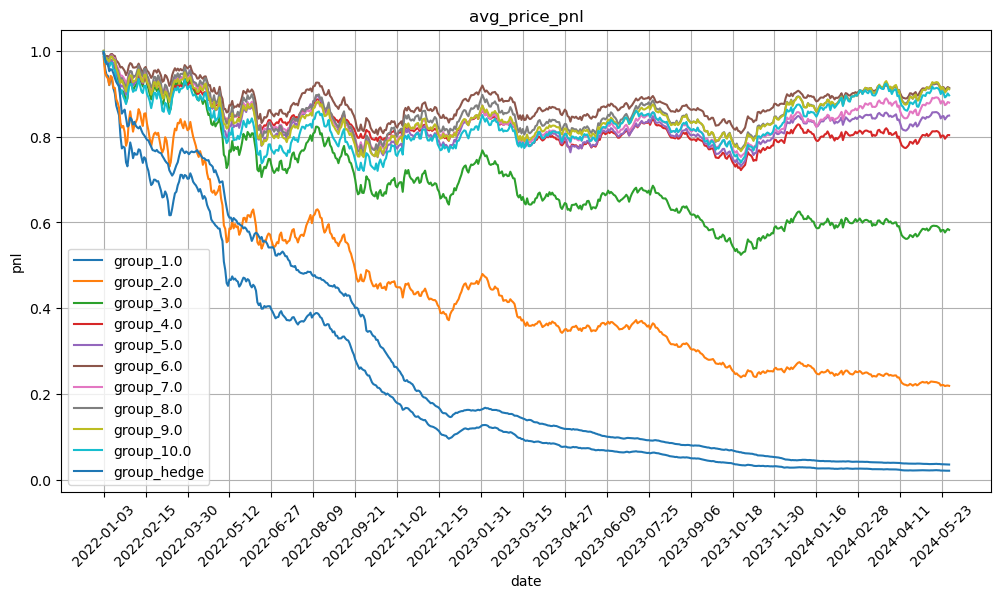

In [8]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Configuration
start_date = '2022-01-01'
end_date = '2024-06-01'
trade_date_path = 'E:\\date.pkl'    #
factor_path = 'E:\\new_feature\\updown2'  #factor
ret_path = 'E:\\return_data_daily'     #ret 
group = [ 0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]  

# Load trade date data
trade_date = pd.read_pickle(trade_date_path)
trade_date = pd.Index(trade_date.astype(str))
trade_date = pd.Index([x[0] for x in trade_date]).to_list()
factor_files = sorted(os.listdir(factor_path))
ret_files = sorted(os.listdir(ret_path))
pnl = {}
ic = {}
result = pd.DataFrame()  


for file in tqdm(factor_files):
    date_tmp = file[:-4]  # 去掉文件后缀，保留日期字符串
    try:
        next_date = trade_date[trade_date.index(date_tmp) + 1]
    except:
        continue
    if file in ret_files and pd.to_datetime(date_tmp) >= pd.to_datetime(start_date) and pd.to_datetime(date_tmp) <= pd.to_datetime(end_date):

        factor_tmp = pd.read_csv(f'{factor_path}/{file}', index_col=0, header=0)
        ret_tmp = pd.read_csv(f'{ret_path}/{next_date}.csv', index_col=1, header=0)
        
        
        index_tmp = factor_tmp.index.intersection(ret_tmp.index)
        
        res_fr = pd.concat([factor_tmp.loc[index_tmp, :],ret_tmp], axis=1)


        for col in factor_tmp.columns.to_list():
            if col not in pnl:     #第一天
                pnl[col] = pd.DataFrame()
                ic[col] = []
                
                

            res_fr[col + '_group'] = pd.qcut(res_fr[col], 10, labels=False, duplicates='drop') + 1

            res_fr['ret_1_pnl'] = res_fr['return']
            result_agg = res_fr.pivot_table(index=col + '_group', values=['ret_1_pnl'], aggfunc=np.mean)

            pnl_tmp = result_agg.T
            pnl_tmp = pnl_tmp.loc[pnl_tmp.index == 'ret_1_pnl']
            pnl_tmp['date'] = date_tmp
            pnl_tmp.set_index('date', inplace=True)
            pnl_tmp.columns.name = None
            pnl_tmp.index.name = None
            pnl[col] = pd.concat([pnl[col], pnl_tmp], axis=0)
            ic_tmp = res_fr[col].corr(res_fr['return'])
            ic[col].append(ic_tmp)

# Calculate effectiveness
for factor in ic:
    pnl[factor]['hedge'] = pnl[factor][1] - pnl[factor][10]   #1-10
    df = pnl[factor]
    cumulative_returns = (1 + df).cumprod()
    dates = df.index
    plt.figure(figsize=(12, 6))
    for group in cumulative_returns.columns:
        plt.plot(dates, cumulative_returns[group], label=f'group_{group}')
    plt.title(factor + '_pnl')
    plt.xlabel('date')
    plt.ylabel('pnl')
    plt.legend()
    plt.grid(True)
    x_ticks_interval = 30
    plt.xticks(dates[::x_ticks_interval], rotation=45)

    ic_tmp = np.mean(ic[factor]).round(4)
    print(factor + '_ic:', ic_tmp)